In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# First Look at Dataset
- Rows: 150
- Columns: 5
    + sepal_length( 35 uniques)
    + sepal width( 23 uniques)
    + petal_length( 43 uniques)
    + petal_petal_width ( 22 uniques)
    + species (3 uniques)
- no null or dummy null such ERROR, UNKNOWN,...

In [47]:
df=pd.read_csv(r"..\data\raw\iris.csv")
#print(df.head())
#print(df.tail())
cols=df.columns.to_list()
print(cols)
print(df.info())
print(df.isnull().sum())
print(df.nunique())

['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.2 KB
None
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64
sepal_length    35
sepal_width     23
petal_length    43
petal_width     22
species          3
dtype: int64


# Check Outliers
- no outliers: sepal_length, petal_length, petal_width
- have outliers but less:  sepal_width #not remove

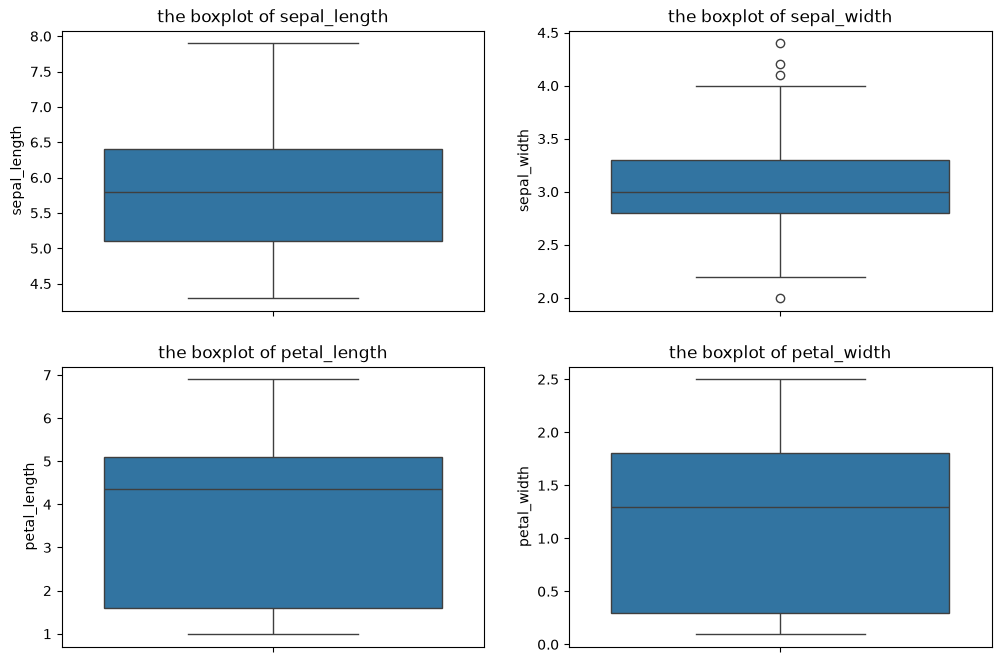

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
target_cols = [col for col in cols if col != "species"]
axes = axes.flatten()   
for i,col in enumerate(target_cols):
    sns.boxplot( y=col, data=df, ax=axes[i])
    axes[i].set_title(f"the boxplot of {col}")
plt.show()



# Distribution of numeric columns
- sepal_length: continuous and skew right lightly ( nearly normal distribution)
- sepal_width: continuous and nealy symmatric( nearly normal distribution)
- petal_length: 2 groups( about 1-2 and 3-7)
- petal_width: 2 groups( about 0-0.5 and 1-2.5)


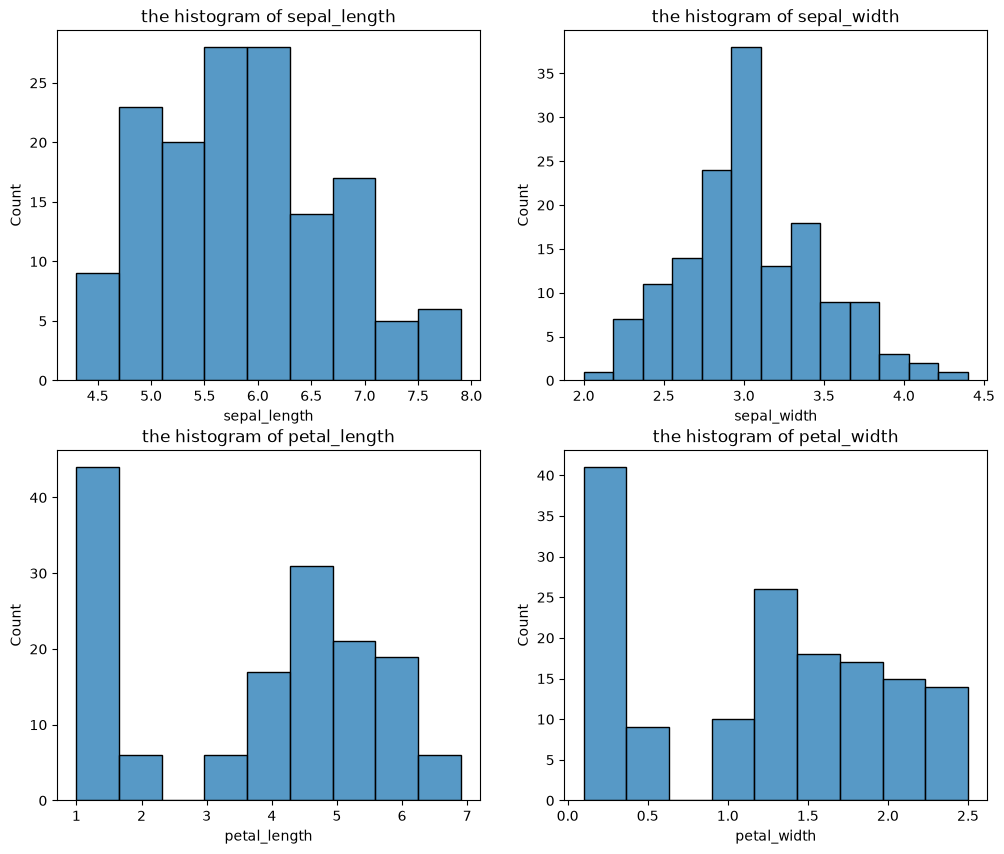

In [51]:
df_describe= df[target_cols].describe()
df_describe.to_csv("../data/processed/describeData.csv")
fig, axes=plt.subplots(2,2,figsize=(12,10))
axes=axes.flatten()
for i, col in enumerate(target_cols):
    sns.histplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(f"the histogram of {col}")
plt.show()

## Correlation
- petal_length & petal_width: very strong positive correlation (0.96) → nearly redundant information
- petal_length & sepal_length: strong positive correlation (0.87)
- petal_width & sepal_length: strong positive correlation (0.82)
- sepal_width & petal_length: moderate negative correlation (-0.42)
- sepal_width & petal_width: moderate negative correlation (-0.36)
- sepal_length & sepal_width: almost no correlation (-0.11)
- petal features (length & width) are highly correlated with each other and with sepal_length => potential multicollinearity for linear-based models

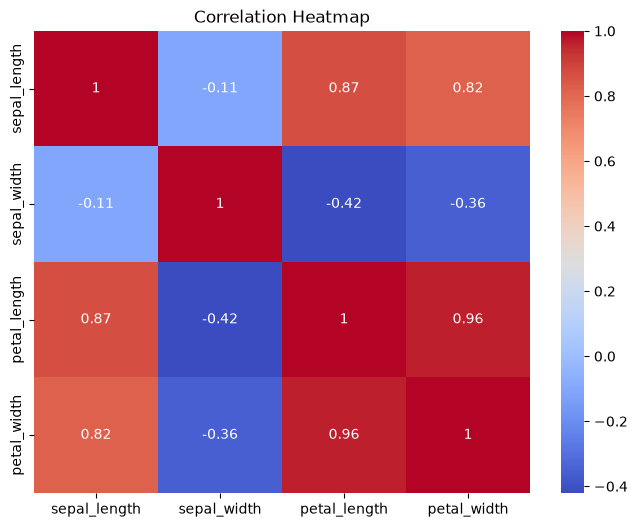

In [57]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[target_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Multivariate Analysis
- setosa is clearly separated from the other two species in almost every feature pair, especially petal_length and petal_width
- versicolor and virginica overlap slightly, mostly in sepal_length and sepal_width
- petal_length and petal_width show the clearest separation between all 3 species → strongest features for classification


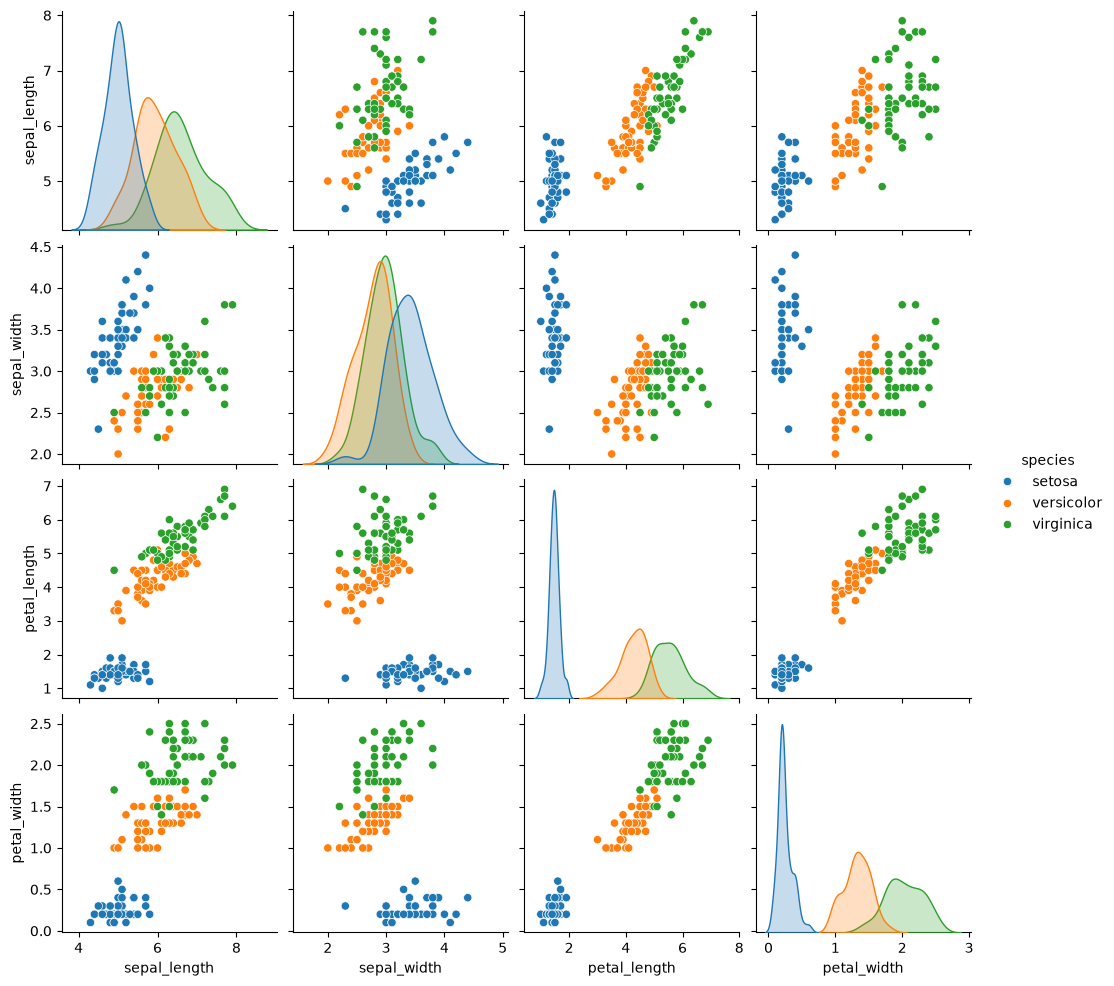

In [60]:
sns.pairplot(df, hue="species")
plt.show()